CHURN PREDICTION USING ANN

In [175]:
import numpy as np
import pandas as pd

In [176]:
df = pd.read_csv("churn.csv")

In [177]:
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [178]:
df.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],
      dtype='object')

In [179]:
df.shape

(10127, 23)

In [180]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [181]:
df.duplicated().sum()

np.int64(0)

In [182]:
df['Attrition_Flag'].value_counts()

Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

In [183]:
df.drop(columns=['CLIENTNUM','Marital_Status','Education_Level'], inplace=True)

In [184]:
df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,Existing Customer,45,M,3,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,Existing Customer,49,F,5,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,Existing Customer,51,M,3,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,Existing Customer,40,F,4,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,Existing Customer,40,M,3,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [185]:
import seaborn as sns
import matplotlib.pyplot as plt

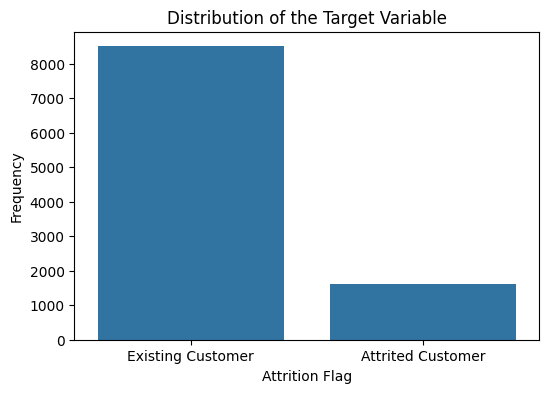

In [186]:
plt.figure(figsize=(6, 4))
sns.countplot(df, x='Attrition_Flag')
plt.title('Distribution of the Target Variable')
plt.xlabel('Attrition Flag')
plt.ylabel('Frequency')
plt.grid(False)
plt.show()

In [187]:
df = pd.get_dummies(df, columns=['Gender', 'Card_Category'], drop_first=True)
for col in df.select_dtypes(['bool']).columns:
    df[col] = df[col].astype(int)


In [173]:
df.head()

,Attrition_Flag,Customer_Age,Dependent_count,Income_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,...,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2,Gender_M,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver
0,Existing Customer,45,3,$60K - $80K,39,5,1,3,12691.0,777,...,1144,42,1.625,0.061,0.000093,0.99991,1,0,0,0
1,Existing Customer,49,5,Less than $40K,44,6,1,2,8256.0,864,...,1291,33,3.714,0.105,0.000057,0.99994,0,0,0,0
2,Existing Customer,51,3,$80K - $120K,36,4,1,0,3418.0,0,...,1887,20,2.333,0.000,0.000021,0.99998,1,0,0,0
3,Existing Customer,40,4,Less than $40K,34,3,4,1,3313.0,2517,...,1171,20,2.333,0.760,0.000134,0.99987,0,0,0,0
4,Existing Customer,40,3,$60K - $80K,21,5,1,0,4716.0,0,...,816,28,2.500,0.000,0.000022,0.99998,1,0,0,0


In [188]:
df = pd.get_dummies(df, columns=['Attrition_Flag', 'Income_Category'], drop_first=True)
for col in df.select_dtypes(['bool']).columns:
    df[col] = df[col].astype(int)

In [189]:
df

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,...,Gender_M,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver,Attrition_Flag_Existing Customer,Income_Category_$40K - $60K,Income_Category_$60K - $80K,Income_Category_$80K - $120K,Income_Category_Less than $40K,Income_Category_Unknown
0,45,3,39,5,1,3,12691.0,777,11914.0,1.335,...,1,0,0,0,1,0,1,0,0,0
1,49,5,44,6,1,2,8256.0,864,7392.0,1.541,...,0,0,0,0,1,0,0,0,1,0
2,51,3,36,4,1,0,3418.0,0,3418.0,2.594,...,1,0,0,0,1,0,0,1,0,0
3,40,4,34,3,4,1,3313.0,2517,796.0,1.405,...,0,0,0,0,1,0,0,0,1,0
4,40,3,21,5,1,0,4716.0,0,4716.0,2.175,...,1,0,0,0,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,50,2,40,3,2,3,4003.0,1851,2152.0,0.703,...,1,0,0,0,1,1,0,0,0,0
10123,41,2,25,4,2,3,4277.0,2186,2091.0,0.804,...,1,0,0,0,0,1,0,0,0,0
10124,44,1,36,5,3,4,5409.0,0,5409.0,0.819,...,0,0,0,0,0,0,0,0,1,0
10125,30,2,36,4,3,3,5281.0,0,5281.0,0.535,...,1,0,0,0,0,1,0,0,0,0


In [190]:
df.columns

Index(['Customer_Age', 'Dependent_count', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2',
       'Gender_M', 'Card_Category_Gold', 'Card_Category_Platinum',
       'Card_Category_Silver', 'Attrition_Flag_Existing Customer',
       'Income_Category_$40K - $60K', 'Income_Category_$60K - $80K',
       'Income_Category_$80K - $120K', 'Income_Category_Less than $40K',
       'Income_Category_Unknown'],
      dtype='object')

In [191]:
print([col for col in X.columns if "Attrition_Flag" in col])

['Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']


In [192]:
X = df.drop(columns=[
    'Attrition_Flag_Existing Customer',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'
])
y = df['Attrition_Flag_Existing Customer']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [193]:
X_train.shape

(8101, 23)

In [194]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [195]:
X_train_scaled

array([[ 0.58297286, -1.79636397, -0.11223016, ..., -0.42269393,
        -0.73631948, -0.35264442],
       [ 1.20636089,  0.50391706,  0.01300077, ..., -0.42269393,
        -0.73631948, -0.35264442],
       [ 0.08426242,  0.50391706,  0.26346261, ..., -0.42269393,
         1.35810613, -0.35264442],
       ...,
       [ 0.58297286, -0.26284329,  0.38869353, ..., -0.42269393,
        -0.73631948, -0.35264442],
       [-0.53912561,  0.50391706, -0.11223016, ..., -0.42269393,
         1.35810613, -0.35264442],
       [ 1.08168329, -0.26284329,  1.51577184, ..., -0.42269393,
        -0.73631948, -0.35264442]], shape=(8101, 23))

In [196]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential 
from tensorflow.keras.layers import Dense

In [221]:
n_features = X_train_scaled.shape[1]
model = Sequential()
model.add(Dense(11, activation='relu', input_shape = (n_features,))) ## used relu instead of sigmoid for a while
model.add(Dense(11, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

C:\Users\Meghali\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [222]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                     │ (None, 11)                  │             264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 11)                  │             132 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 1)                   │              12 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 408 (1.59 KB)

 Trainable params: 408 (1.59 KB)

 Non-trainable params: 0 (0.00 B)

In [223]:
model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [224]:
history = model.fit(X_train_scaled, y_train, epochs=50,  validation_split=0.2)  ##increased epoch

Epoch 1/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6907 - loss: 0.5940 - val_accuracy: 0.8575 - val_loss: 0.3782
Epoch 2/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8778 - loss: 0.3235 - val_accuracy: 0.8871 - val_loss: 0.2807
Epoch 3/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8920 - loss: 0.2733 - val_accuracy: 0.8890 - val_loss: 0.2578
Epoch 4/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8985 - loss: 0.2543 - val_accuracy: 0.9001 - val_loss: 0.2475
Epoch 5/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9032 - loss: 0.2412 - val_accuracy: 0.9025 - val_loss: 0.2396
Epoch 6/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9059 - loss: 0.2319 - val_accuracy: 0.9056 - val_loss: 0.2297
Epoch 7/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9113 - loss: 0.2239 - val_accuracy: 0.9081 - val_loss: 0.2244
Epoch 8/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9148 - loss: 0.2168 - val_accuracy: 0.

In [225]:
model.layers[0].get_weights()

[array([[-1.15704916e-01,  1.28107861e-01,  1.19229749e-01,
         -1.89929120e-02, -2.22955793e-01,  1.16213508e-01,
         -1.16611414e-01,  2.12889850e-01, -7.40467012e-02,
          8.13269392e-02, -1.76371276e-01],
        [-4.84585986e-02,  1.43508436e-02,  7.12992027e-02,
          6.28734306e-02, -1.44801497e-01,  1.36029571e-01,
         -3.77955317e-01,  2.37403408e-01,  3.12599421e-01,
         -1.42382726e-01,  5.88188052e-01],
        [ 1.98920593e-01,  2.73693144e-01, -1.47949914e-02,
          8.10300335e-02,  9.55805629e-02,  9.81479809e-02,
         -7.21063912e-02,  2.46355265e-01,  1.26524031e-01,
         -3.02142292e-01,  8.26689079e-02],
        [-4.05159324e-01, -1.36331758e-02, -2.10160211e-01,
          3.98624748e-01,  8.06240559e-01, -7.65434504e-01,
          5.57706840e-02,  1.33752331e-01, -6.32500350e-02,
         -1.28890678e-01,  5.11262715e-01],
        [ 6.34431913e-02, -4.68438894e-01, -1.80595517e-02,
          1.88750148e-01,  2.37668399e-02,  

In [226]:
model.layers[1].get_weights()

[array([[-5.65715916e-02,  2.87450731e-01,  3.98698688e-01,
         -5.12968600e-01, -6.58015788e-01, -2.38296926e-01,
          6.39697433e-01,  3.90947849e-01,  2.20259786e-01,
         -3.40450287e-01, -1.87244296e-01],
        [-2.96004623e-01,  3.82866204e-01, -6.88250959e-01,
          8.62539164e-04, -2.69988418e-01,  5.74080825e-01,
         -3.91904145e-01, -6.09706044e-01,  6.87628269e-01,
          4.39069599e-01,  2.59573311e-01],
        [ 1.80069767e-02,  6.24968469e-01,  5.54793000e-01,
          1.91857666e-01,  3.64326924e-01, -5.68544529e-02,
          5.07439911e-01,  5.55759549e-01, -5.86006045e-01,
         -1.73623815e-01, -3.66210798e-03],
        [ 3.21122110e-01,  2.52684448e-02, -5.14376879e-01,
          2.68426120e-01,  5.21116005e-03, -6.10856056e-01,
         -2.02664994e-02, -1.09908223e+00,  3.78469680e-03,
          2.45422930e-01,  5.12858093e-01],
        [-7.84762442e-01, -2.29690373e-01,  7.78968692e-01,
          3.49634498e-01, -3.30316544e-01,  

In [227]:
model.predict(X_test_scaled)

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


array([[0.99979377],
       [0.9999652 ],
       [0.9224871 ],
       ...,
       [0.9970938 ],
       [0.99887866],
       [0.98418134]], shape=(2026, 1), dtype=float32)

In [228]:
y_log = model.predict(X_test_scaled)

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


In [229]:
y_pred = np.where(y_log>0.5,1,0)

In [230]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9294175715695953

In [231]:
history.history

{'accuracy': [0.6907407641410828,
  0.8777777552604675,
  0.8919752836227417,
  0.8984568119049072,
  0.9032407402992249,
  0.9058641791343689,
  0.9112654328346252,
  0.914814829826355,
  0.917438268661499,
  0.918055534362793,
  0.9199073910713196,
  0.9212962985038757,
  0.9225308895111084,
  0.9237654209136963,
  0.9248456954956055,
  0.9256172776222229,
  0.9282407164573669,
  0.9277777671813965,
  0.9274691343307495,
  0.9297839403152466,
  0.9294753074645996,
  0.9328703880310059,
  0.9331790208816528,
  0.9344135522842407,
  0.9336419701576233,
  0.9359567761421204,
  0.9354938268661499,
  0.9353395104408264,
  0.937191367149353,
  0.934876561164856,
  0.9367284178733826,
  0.9364197254180908,
  0.9356481432914734,
  0.936882734298706,
  0.938117265701294,
  0.9364197254180908,
  0.9388889074325562,
  0.9365741014480591,
  0.9382715821266174,
  0.9393518567085266,
  0.937808632850647,
  0.9379629492759705,
  0.9395061731338501,
  0.9393518567085266,
  0.9379629492759705,
  0.93

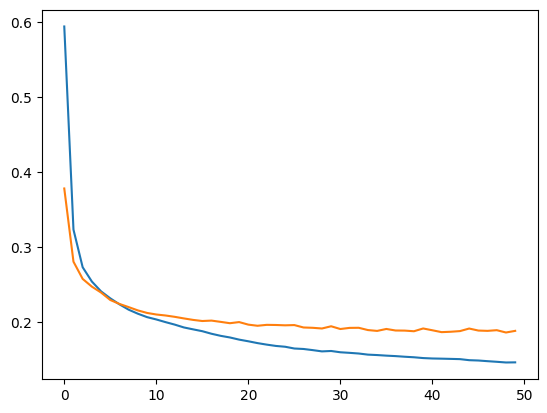

In [232]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])